<a href="https://colab.research.google.com/github/ferhat00/LLM/blob/main/fpl_poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FPL Squad Optimiser with Poisson Regression

**Domain-Specific Statistical Approach**

FPL points come from **discrete events**: goals, assists, clean sheets, bonus points, saves.
Poisson regression is the natural model for count data!

**How it works:**
1. **Separate Poisson models** for each event type (goals, assists, bonus, saves)
2. **Logistic regression** for clean sheet probability
3. **Combine predictions** using exact FPL scoring rules
4. **Position-specific models** (different features matter for GKP vs FWD)

**FPL Scoring System:**
- Goals: GKP/DEF=6pts, MID=5pts, FWD=4pts
- Assists: 3pts all positions
- Clean sheets: GKP/DEF=4pts, MID=1pt
- Bonus: 1-3pts
- Saves: 1pt per 3 saves (GKP)
- Minutes: 1pt (1-59min), 2pts (60+)

**Updated:** 2025

In [1]:
# Install packages
!pip install pulp statsmodels --quiet 2>/dev/null

import pulp
import statsmodels.api as sm
print(f"✅ PuLP installed")
print(f"✅ Statsmodels: {sm.__version__}")

✅ PuLP installed
✅ Statsmodels: 0.14.5


In [2]:
from __future__ import annotations
import json, requests, warnings, os
from pathlib import Path
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson, NegativeBinomial, Binomial
from statsmodels.genmod.generalized_linear_model import GLM
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import mean_absolute_error
import pulp

warnings.filterwarnings('ignore')
print("✅ All packages loaded!")

✅ All packages loaded!


In [3]:
# ----------------------------------------------------------------------
# FPL SCORING RULES
# ----------------------------------------------------------------------

@dataclass
class FPLScoring:
    """Official FPL scoring rules."""
    # Goals
    GOAL_GKP: int = 6
    GOAL_DEF: int = 6
    GOAL_MID: int = 5
    GOAL_FWD: int = 4

    # Assists
    ASSIST: int = 3

    # Clean sheets
    CS_GKP: int = 4
    CS_DEF: int = 4
    CS_MID: int = 1
    CS_FWD: int = 0

    # Minutes
    MINS_1_59: int = 1
    MINS_60_PLUS: int = 2

    # Other
    SAVE_POINTS: float = 1/3  # 1 point per 3 saves
    BONUS_MAX: int = 3

    # Negative
    GOALS_CONCEDED_PER_2: int = -1  # GKP/DEF only
    YELLOW: int = -1
    RED: int = -3
    OWN_GOAL: int = -2
    PEN_MISS: int = -2
    PEN_SAVE: int = 5

SCORING = FPLScoring()

def calculate_expected_points(position: str, goals: float, assists: float,
                               cs_prob: float, bonus: float, saves: float = 0,
                               minutes_prob: float = 0.8) -> float:
    """
    Calculate expected FPL points from predicted event rates.

    Args:
        position: GKP, DEF, MID, FWD
        goals: Expected goals (λ from Poisson)
        assists: Expected assists (λ from Poisson)
        cs_prob: Clean sheet probability
        bonus: Expected bonus points
        saves: Expected saves (GKP only)
        minutes_prob: Probability of playing 60+ minutes
    """
    pts = 0.0

    # Minutes contribution
    pts += minutes_prob * SCORING.MINS_60_PLUS + (1 - minutes_prob) * 0.5 * SCORING.MINS_1_59

    # Goals
    goal_pts = {'GKP': SCORING.GOAL_GKP, 'DEF': SCORING.GOAL_DEF,
                'MID': SCORING.GOAL_MID, 'FWD': SCORING.GOAL_FWD}
    pts += goals * goal_pts.get(position, 4)

    # Assists
    pts += assists * SCORING.ASSIST

    # Clean sheets
    cs_pts = {'GKP': SCORING.CS_GKP, 'DEF': SCORING.CS_DEF,
              'MID': SCORING.CS_MID, 'FWD': SCORING.CS_FWD}
    pts += cs_prob * cs_pts.get(position, 0) * minutes_prob  # Only if 60+ mins

    # Bonus
    pts += min(bonus, SCORING.BONUS_MAX)

    # Saves (GKP only)
    if position == 'GKP':
        pts += saves * SCORING.SAVE_POINTS

    return max(0, pts)

print("📊 FPL Scoring rules loaded")
print(f"   Goal points: GKP/DEF={SCORING.GOAL_GKP}, MID={SCORING.GOAL_MID}, FWD={SCORING.GOAL_FWD}")
print(f"   CS points: GKP/DEF={SCORING.CS_GKP}, MID={SCORING.CS_MID}")

📊 FPL Scoring rules loaded
   Goal points: GKP/DEF=6, MID=5, FWD=4
   CS points: GKP/DEF=4, MID=1


In [10]:
import json, requests, warnings, os
from pathlib import Path
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson, NegativeBinomial, Binomial
from statsmodels.genmod.generalized_linear_model import GLM
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import mean_absolute_error
import pulp

warnings.filterwarnings('ignore')
print("✅ All packages loaded!")

# ----------------------------------------------------------------------
# FPL SCORING RULES
# ----------------------------------------------------------------------

@dataclass
class FPLScoring:
    """Official FPL scoring rules."""
    # Goals
    GOAL_GKP: int = 6
    GOAL_DEF: int = 6
    GOAL_MID: int = 5
    GOAL_FWD: int = 4

    # Assists
    ASSIST: int = 3

    # Clean sheets
    CS_GKP: int = 4
    CS_DEF: int = 4
    CS_MID: int = 1
    CS_FWD: int = 0

    # Minutes
    MINS_1_59: int = 1
    MINS_60_PLUS: int = 2

    # Other
    SAVE_POINTS: float = 1/3  # 1 point per 3 saves
    BONUS_MAX: int = 3

    # Negative
    GOALS_CONCEDED_PER_2: int = -1  # GKP/DEF only
    YELLOW: int = -1
    RED: int = -3
    OWN_GOAL: int = -2
    PEN_MISS: int = -2
    PEN_SAVE: int = 5

SCORING = FPLScoring()

def calculate_expected_points(position: str, goals: float, assists: float,
                               cs_prob: float, bonus: float, saves: float = 0,
                               minutes_prob: float = 0.8) -> float:
    """
    Calculate expected FPL points from predicted event rates.

    Args:
        position: GKP, DEF, MID, FWD
        goals: Expected goals (λ from Poisson)
        assists: Expected assists (λ from Poisson)
        cs_prob: Clean sheet probability
        bonus: Expected bonus points
        saves: Expected saves (GKP only)
        minutes_prob: Probability of playing 60+ minutes
    """
    pts = 0.0

    # Minutes contribution
    pts += minutes_prob * SCORING.MINS_60_PLUS + (1 - minutes_prob) * 0.5 * SCORING.MINS_1_59

    # Goals
    goal_pts = {'GKP': SCORING.GOAL_GKP, 'DEF': SCORING.GOAL_DEF,
                'MID': SCORING.GOAL_MID, 'FWD': SCORING.GOAL_FWD}
    pts += goals * goal_pts.get(position, 4)

    # Assists
    pts += assists * SCORING.ASSIST

    # Clean sheets
    cs_pts = {'GKP': SCORING.CS_GKP, 'DEF': SCORING.CS_DEF,
              'MID': SCORING.CS_MID, 'FWD': SCORING.CS_FWD}
    pts += cs_prob * cs_pts.get(position, 0) * minutes_prob  # Only if 60+ mins

    # Bonus
    pts += min(bonus, SCORING.BONUS_MAX)

    # Saves (GKP only)
    if position == 'GKP':
        pts += saves * SCORING.SAVE_POINTS

    return max(0, pts)

print("📊 FPL Scoring rules loaded")
print(f"   Goal points: GKP/DEF={SCORING.GOAL_GKP}, MID={SCORING.GOAL_MID}, FWD={SCORING.GOAL_FWD}")
print(f"   CS points: GKP/DEF={SCORING.CS_GKP}, MID={SCORING.CS_MID}")

# ----------------------------------------------------------------------
# DATA FETCHING
# ----------------------------------------------------------------------

SEASONS = ['2024-25', '2023-24', '2022-23']
GITHUB_BASE = "https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data"

def fetch_current_season(verify_ssl=True):
    """Fetch current season GW data."""
    print("\n📡 Fetching 2024-25 data...")
    if not verify_ssl:
        import urllib3
        urllib3.disable_warnings()

    try:
        resp = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=30, verify=verify_ssl)
        data = resp.json()
    except Exception as e:
        print(f"   ❌ {e}")
        return pd.DataFrame(), pd.DataFrame()

    teams = {t['id']: t['name'] for t in data['teams']}
    positions = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}

    # Team strengths for features
    team_strength = {t['id']: {
        'attack': t.get('strength_attack_home', 1000) + t.get('strength_attack_away', 1000),
        'defence': t.get('strength_defence_home', 1000) + t.get('strength_defence_away', 1000)
    } for t in data['teams']}

    players = [{
        'player_id': p['id'], 'name': p['web_name'],
        'team': teams[p['team']], 'team_id': p['team'],
        'position': positions[p['element_type']],
        'price': p['now_cost']/10.0, 'status': p['status'],
        'form': float(p['form'] or 0),
        'selected_by_percent': float(p['selected_by_percent']),
        'total_points': p['total_points'],
        'team_attack': team_strength[p['team']]['attack'],
        'team_defence': team_strength[p['team']]['defence'],
        'season': '2024-25'
    } for p in data['elements']]
    player_df = pd.DataFrame(players)

    # Fetch GW histories
    print(f"   Fetching GW histories for {len(player_df)} players...")
    gw_records = []
    for idx, row in player_df.iterrows():
        if (idx+1) % 100 == 0: print(f"   Progress: {idx+1}/{len(player_df)}")
        try:
            r = requests.get(f"https://fantasy.premierleague.com/api/element-summary/{row['player_id']}/",
                           timeout=10, verify=verify_ssl)
            for gw in r.json().get('history', []):
                gw_records.append({
                    'player_id': row['player_id'],
                    'position': row['position'],
                    'team_attack': row['team_attack'],
                    'team_defence': row['team_defence'],
                    'season': '2024-25',
                    'gameweek': gw.get('round', 0),
                    'minutes': gw.get('minutes', 0),
                    'goals_scored': gw.get('goals_scored', 0),
                    'assists': gw.get('assists', 0),
                    'clean_sheets': gw.get('clean_sheets', 0),
                    'goals_conceded': gw.get('goals_conceded', 0),
                    'bonus': gw.get('bonus', 0),
                    'bps': gw.get('bps', 0),
                    'saves': gw.get('saves', 0),
                    'influence': float(gw.get('influence', 0)),
                    'creativity': float(gw.get('creativity', 0)),
                    'threat': float(gw.get('threat', 0)),
                    'ict_index': float(gw.get('ict_index', 0)),
                    'expected_goals': float(gw.get('expected_goals', 0) or 0),
                    'expected_assists': float(gw.get('expected_assists', 0) or 0),
                    'total_points': gw.get('total_points', 0),
                    'value': gw.get('value', 0) / 10.0,
                    'was_home': gw.get('was_home', False),
                })
        except: continue

    gw_df = pd.DataFrame(gw_records)
    print(f"   ✅ {len(gw_df)} GW records")
    return player_df, gw_df


def fetch_historical(season):
    """Fetch historical season data."""
    print(f"\n📡 Fetching {season}...")
    urls = [f"{GITHUB_BASE}/{season}/gws/merged_gw.csv"]

    for url in urls:
        try:
            df = pd.read_csv(url)

            # Handle 'element' to 'player_id'
            if 'element' in df.columns:
                df.rename(columns={'element': 'player_id'}, inplace=True)

            # Handle 'GW' or 'round' to 'gameweek' to ensure unique column name
            if 'GW' in df.columns:
                df.rename(columns={'GW': 'gameweek'}, inplace=True)
                if 'round' in df.columns: # If 'round' also exists, drop it to avoid duplicates
                    df.drop(columns=['round'], inplace=True, errors='ignore')
            elif 'round' in df.columns:
                df.rename(columns={'round': 'gameweek'}, inplace=True)

            df['season'] = season

            # Map position from element_type if available
            if 'position' not in df.columns and 'element_type' in df.columns:
                df['position'] = df['element_type'].map({1:'GKP', 2:'DEF', 3:'MID', 4:'FWD'})

            # Ensure columns exist
            for col in ['goals_scored','assists','clean_sheets','bonus','saves','minutes',
                       'influence','creativity','threat','expected_goals','expected_assists',
                       'goals_conceded','bps','total_points']:
                if col not in df.columns: df[col] = 0

            # Add placeholder team strengths
            df['team_attack'] = 2000
            df['team_defence'] = 2000
            df['was_home'] = True  # Default

            print(f"   ✅ {len(df)} records")
            return df
        except Exception as e:
            print(f"   ⚠️ Could not fetch {season}. Error: {e}")
            continue
    print(f"   ⚠️ Could not fetch {season}")
    return pd.DataFrame()


def fetch_all_data(verify_ssl=True):
    """Fetch all seasons."""
    print("\n" + "="*70)
    print("📊 FETCHING MULTI-SEASON DATA FOR POISSON MODELS")
    print("="*70)

    current_players, current_gw = fetch_current_season(verify_ssl)
    hist_dfs = [fetch_historical(s) for s in SEASONS[1:]]
    hist_dfs = [df for df in hist_dfs if not df.empty]

    all_gw = pd.concat([current_gw] + hist_dfs, ignore_index=True) if not current_gw.empty else pd.concat(hist_dfs, ignore_index=True)

    print(f"\n📈 Total: {len(all_gw)} gameweek observations")
    print(f"   Goals: {all_gw['goals_scored'].sum():.0f} total, {all_gw['goals_scored'].mean():.3f} per game")
    print(f"   Assists: {all_gw['assists'].sum():.0f} total, {all_gw['assists'].mean():.3f} per game")
    print(f"   CS: {all_gw['clean_sheets'].sum():.0f} total, {all_gw['clean_sheets'].mean():.3f} per game")

    return current_players, current_gw, all_gw

✅ All packages loaded!
📊 FPL Scoring rules loaded
   Goal points: GKP/DEF=6, MID=5, FWD=4
   CS points: GKP/DEF=4, MID=1


In [11]:
# ----------------------------------------------------------------------
# POISSON REGRESSION MODELS
# ----------------------------------------------------------------------

class PoissonFPLModel:
    """
    Poisson regression models for FPL event prediction.

    Builds separate models for:
    - Goals (Poisson)
    - Assists (Poisson)
    - Bonus (Poisson/Negative Binomial)
    - Clean sheets (Logistic)
    - Saves (Poisson, GKP only)
    """

    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_cols = {}

    def _get_features(self, df: pd.DataFrame, position: str, target: str) -> Tuple[np.ndarray, List[str]]:
        """
        Get relevant features for each target variable.
        Different positions use different features.
        """
        base_features = ['influence', 'creativity', 'threat', 'ict_index', 'minutes']

        if target == 'goals_scored':
            if position in ['FWD', 'MID']:
                features = ['threat', 'influence', 'expected_goals', 'minutes', 'ict_index']
            else:
                features = ['threat', 'influence', 'minutes']

        elif target == 'assists':
            features = ['creativity', 'influence', 'expected_assists', 'minutes', 'ict_index']

        elif target == 'clean_sheets':
            features = ['minutes', 'team_defence']

        elif target == 'bonus':
            features = ['bps', 'influence', 'threat', 'creativity', 'minutes']

        elif target == 'saves':
            features = ['minutes', 'team_defence']

        else:
            features = base_features

        # Filter to existing columns
        features = [f for f in features if f in df.columns]
        X = df[features].fillna(0).values

        return X, features

    def fit(self, df: pd.DataFrame, verbose: bool = True):
        """
        Fit all Poisson models on training data.
        """
        if verbose:
            print("\n" + "="*70)
            print("🎯 TRAINING POISSON REGRESSION MODELS")
            print("="*70)

        # Filter to players who played
        df = df[df['minutes'] > 0].copy()

        targets = {
            'goals_scored': {'family': 'poisson', 'positions': ['GKP', 'DEF', 'MID', 'FWD']},
            'assists': {'family': 'poisson', 'positions': ['GKP', 'DEF', 'MID', 'FWD']},
            'bonus': {'family': 'poisson', 'positions': ['GKP', 'DEF', 'MID', 'FWD']},
            'clean_sheets': {'family': 'logistic', 'positions': ['GKP', 'DEF', 'MID']},
            'saves': {'family': 'poisson', 'positions': ['GKP']},
        }

        for target, config in targets.items():
            if verbose:
                print(f"\n📊 Training {target} model ({config['family']})...")

            for position in config['positions']:
                pos_df = df[df['position'] == position].copy()

                if len(pos_df) < 50:
                    continue

                X, features = self._get_features(pos_df, position, target)
                y = pos_df[target].fillna(0).values

                # Scale features
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X)

                # Add constant for statsmodels
                X_with_const = sm.add_constant(X_scaled)

                try:
                    if config['family'] == 'poisson':
                        model = GLM(y, X_with_const, family=Poisson()).fit(disp=0)
                    elif config['family'] == 'logistic':
                        model = LogisticRegression(max_iter=1000, random_state=42)
                        model.fit(X_scaled, y)

                    key = f"{target}_{position}"
                    self.models[key] = model
                    self.scalers[key] = scaler
                    self.feature_cols[key] = features

                    if verbose:
                        if config['family'] == 'poisson':
                            print(f"   {position}: λ_mean={np.exp(model.params[0]):.4f}, n={len(pos_df)}")
                        else:
                            print(f"   {position}: n={len(pos_df)}")

                except Exception as e:
                    if verbose:
                        print(f"   {position}: ⚠️ {e}")

        if verbose:
            print(f"\n✅ Trained {len(self.models)} models")

        return self

    def predict_events(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Predict expected events for each player.
        """
        results = []

        for _, row in df.iterrows():
            position = row['position']

            pred = {
                'player_id': row['player_id'],
                'position': position,
                'exp_goals': 0,
                'exp_assists': 0,
                'exp_bonus': 0,
                'exp_cs_prob': 0,
                'exp_saves': 0,
                'minutes_prob': 0.8,  # Default
            }

            # Predict each event type
            for target in ['goals_scored', 'assists', 'bonus', 'clean_sheets', 'saves']:
                key = f"{target}_{position}"

                if key not in self.models:
                    continue

                model = self.models[key]
                scaler = self.scalers[key]
                features = self.feature_cols[key]

                # Get features for this player
                X = row[features].fillna(0).values.reshape(1, -1)
                X_scaled = scaler.transform(X)

                if target == 'clean_sheets':
                    # Logistic model - predict probability
                    prob = model.predict_proba(X_scaled)[0, 1]
                    pred['exp_cs_prob'] = prob
                else:
                    # Poisson model - predict lambda (expected count)
                    X_with_const = sm.add_constant(X_scaled, has_constant='add')
                    lambda_pred = model.predict(X_with_const)[0]

                    if target == 'goals_scored':
                        pred['exp_goals'] = lambda_pred
                    elif target == 'assists':
                        pred['exp_assists'] = lambda_pred
                    elif target == 'bonus':
                        pred['exp_bonus'] = min(lambda_pred, 3)  # Cap at 3
                    elif target == 'saves':
                        pred['exp_saves'] = lambda_pred

            results.append(pred)

        return pd.DataFrame(results)

    def predict_points(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Predict expected FPL points using Poisson event predictions.
        """
        # Get event predictions
        events = self.predict_events(df)

        # Calculate expected points
        points = []
        for _, row in events.iterrows():
            exp_pts = calculate_expected_points(
                position=row['position'],
                goals=row['exp_goals'],
                assists=row['exp_assists'],
                cs_prob=row['exp_cs_prob'],
                bonus=row['exp_bonus'],
                saves=row['exp_saves'],
                minutes_prob=row['minutes_prob']
            )
            points.append({
                'player_id': row['player_id'],
                'predicted_points': exp_pts,
                'exp_goals': row['exp_goals'],
                'exp_assists': row['exp_assists'],
                'exp_cs_prob': row['exp_cs_prob'],
                'exp_bonus': row['exp_bonus'],
            })

        return pd.DataFrame(points)


print("📊 PoissonFPLModel class defined")

📊 PoissonFPLModel class defined


In [12]:
# ----------------------------------------------------------------------
# FEATURE ENGINEERING FOR PREDICTION
# ----------------------------------------------------------------------

def prepare_prediction_features(current_players: pd.DataFrame,
                                  current_gw: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for current players based on their recent history.
    Uses rolling averages from recent gameweeks.
    """
    print("\n🔧 Preparing prediction features...")

    feature_cols = ['minutes', 'influence', 'creativity', 'threat', 'ict_index',
                    'expected_goals', 'expected_assists', 'bps', 'saves']

    # Calculate rolling averages for each player
    player_features = []

    for pid in current_players['player_id'].unique():
        player_gw = current_gw[current_gw['player_id'] == pid].sort_values('gameweek')
        player_info = current_players[current_players['player_id'] == pid].iloc[0]

        if len(player_gw) >= 3:
            # Use last 5 games average (or all if less)
            recent = player_gw.tail(5)

            features = {
                'player_id': pid,
                'position': player_info['position'],
                'team_defence': player_info.get('team_defence', 2000),
                'team_attack': player_info.get('team_attack', 2000),
            }

            for col in feature_cols:
                if col in recent.columns:
                    features[col] = recent[col].mean()
                else:
                    features[col] = 0

            # Minutes probability based on recent starts
            features['minutes_prob'] = (recent['minutes'] >= 60).mean()

        else:
            # Use season averages or form
            features = {
                'player_id': pid,
                'position': player_info['position'],
                'team_defence': player_info.get('team_defence', 2000),
                'team_attack': player_info.get('team_attack', 2000),
                'minutes': 60,
                'influence': player_info.get('form', 2) * 10,
                'creativity': player_info.get('form', 2) * 10,
                'threat': player_info.get('form', 2) * 10,
                'ict_index': player_info.get('form', 2) * 5,
                'expected_goals': 0.1 if player_info['position'] in ['FWD', 'MID'] else 0.01,
                'expected_assists': 0.1 if player_info['position'] in ['MID', 'FWD'] else 0.05,
                'bps': 15,
                'saves': 3 if player_info['position'] == 'GKP' else 0,
                'minutes_prob': 0.5,
            }

        player_features.append(features)

    result = pd.DataFrame(player_features)
    print(f"   ✅ Features prepared for {len(result)} players")

    return result

In [13]:
# ----------------------------------------------------------------------
# SQUAD & TRANSFER FUNCTIONS
# ----------------------------------------------------------------------

def get_squad(df):
    """Interactive squad entry."""
    print("\n" + "="*70 + "\n📋 ENTER YOUR SQUAD\n" + "="*70)
    squad, pos_cnt = [], {'GKP':0,'DEF':0,'MID':0,'FWD':0}
    pos_lim = {'GKP':2,'DEF':5,'MID':5,'FWD':3}

    while len(squad) < 15:
        print(f"\n[{len(squad)}/15] GKP:{pos_cnt['GKP']}/2 DEF:{pos_cnt['DEF']}/5 MID:{pos_cnt['MID']}/5 FWD:{pos_cnt['FWD']}/3")
        inp = input(f"Player {len(squad)+1}: ").strip()

        if inp.lower() == 'list':
            pos = input("Position: ").upper()
            if pos in pos_lim: print(df[df['position']==pos][['player_id','name','team','price']].head(30).to_string())
            continue

        m = df[df['player_id']==int(inp)] if inp.isdigit() else df[df['name'].str.lower().str.contains(inp.lower(), na=False)]
        if len(m) == 0: print("❌ Not found"); continue
        if len(m) > 1: print("Multiple:"); print(m[['player_id','name','team','position']].head(8).to_string()); continue

        p = m.iloc[0]
        if p['player_id'] in squad: print("❌ Already added"); continue
        if pos_cnt[p['position']] >= pos_lim[p['position']]: print(f"❌ Max {p['position']}"); continue
        if [df.loc[df['player_id']==s,'team'].iloc[0] for s in squad].count(p['team']) >= 3: print("❌ Max 3/team"); continue

        squad.append(p['player_id'])
        pos_cnt[p['position']] += 1
        print(f"✅ {p['name']} ({p['team']}, {p['position']}, £{p['price']:.1f}m)")
    return squad


def display_squad(squad, df):
    """Display squad with Poisson predictions breakdown."""
    print("\n" + "="*70 + "\n📊 YOUR SQUAD (Poisson Predictions)\n" + "="*70)
    sq = df[df['player_id'].isin(squad)]

    for pos in ['GKP','DEF','MID','FWD']:
        print(f"\n{pos}:")
        for _,p in sq[sq['position']==pos].iterrows():
            g = p.get('exp_goals', 0)
            a = p.get('exp_assists', 0)
            cs = p.get('exp_cs_prob', 0)
            breakdown = f"G:{g:.2f} A:{a:.2f}" + (f" CS:{cs:.0%}" if pos in ['GKP','DEF'] else "")
            print(f"  {p['name']:<18} {p['team']:<14} £{p['price']:.1f}m  {p['predicted_points']:.2f}pts ({breakdown})")

    print(f"\n💰 £{sq['price'].sum():.1f}m | Bank: £{100-sq['price'].sum():.1f}m")
    print(f"📈 Predicted (best 11): {calc_best11(squad, df):.2f}")


def calc_best11(squad, df):
    sq = df[df['player_id'].isin(squad)]
    sel = sq[sq['position']=='DEF'].nlargest(3,'predicted_points')['player_id'].tolist()
    sel += sq[sq['position']=='MID'].nlargest(2,'predicted_points')['player_id'].tolist()
    sel += sq[sq['position']=='FWD'].nlargest(1,'predicted_points')['player_id'].tolist()
    sel += sq[(~sq['player_id'].isin(sel))&(sq['position']!='GKP')].nlargest(4,'predicted_points')['player_id'].tolist()
    gkp = sq[sq['position']=='GKP'].nlargest(1,'predicted_points')
    pts = gkp['predicted_points'].sum() + sq[sq['player_id'].isin(sel)]['predicted_points'].sum()
    return pts + pd.concat([gkp, sq[sq['player_id'].isin(sel)]])['predicted_points'].max()


def sample_squad(df):
    print("\n📋 Sample squad...")
    sq = df[df['position']=='GKP'].nsmallest(2,'price')['player_id'].tolist()
    sq += df[df['position']=='DEF'].nsmallest(5,'price')['player_id'].tolist()
    sq += df[df['position']=='MID'].nsmallest(5,'price')['player_id'].tolist()
    sq += df[df['position']=='FWD'].nsmallest(3,'price')['player_id'].tolist()
    return sq

In [14]:
# ----------------------------------------------------------------------
# TRANSFER OPTIMIZATION
# ----------------------------------------------------------------------

def optimize_transfers(squad, df, n_transfers, budget=100.0):
    """MILP transfer optimization."""
    print(f"\n🔄 Optimizing {n_transfers} transfer(s)...")
    sq_df = df[df['player_id'].isin(squad)]
    val, bank = sq_df['price'].sum(), budget - sq_df['price'].sum()

    pids = df['player_id'].tolist()
    price = dict(zip(pids, df['price']))
    pos = dict(zip(pids, df['position']))
    team = dict(zip(pids, df['team']))
    pts = dict(zip(pids, df['predicted_points']))

    prob = pulp.LpProblem("FPL", pulp.LpMaximize)
    new_sq = pulp.LpVariable.dicts("sq", pids, cat="Binary")
    t_out = pulp.LpVariable.dicts("out", pids, cat="Binary")
    t_in = pulp.LpVariable.dicts("in", pids, cat="Binary")
    start = pulp.LpVariable.dicts("st", pids, cat="Binary")
    cap = pulp.LpVariable.dicts("c", pids, cat="Binary")

    prob += pulp.lpSum(pts[i]*(start[i]+cap[i]) for i in pids)

    for i in pids:
        prob += (new_sq[i] == 1-t_out[i]) if i in squad else (new_sq[i] == t_in[i])

    prob += pulp.lpSum(t_out[i] for i in pids) == n_transfers
    prob += pulp.lpSum(t_in[i] for i in pids) == n_transfers
    prob += pulp.lpSum(new_sq[i] for i in pids) == 15
    prob += pulp.lpSum(price[i]*new_sq[i] for i in pids) <= val+bank

    for p,lim in {'GKP':2,'DEF':5,'MID':5,'FWD':3}.items():
        prob += pulp.lpSum(new_sq[i] for i in pids if pos[i]==p) == lim
    for t in df['team'].unique():
        prob += pulp.lpSum(new_sq[i] for i in pids if team[i]==t) <= 3

    prob += pulp.lpSum(start[i] for i in pids) == 11
    for i in pids: prob += start[i] <= new_sq[i]
    prob += pulp.lpSum(start[i] for i in pids if pos[i]=='GKP') == 1
    for p,mn,mx in [('DEF',3,5),('MID',2,5),('FWD',1,3)]:
        prob += pulp.lpSum(start[i] for i in pids if pos[i]==p) >= mn
        prob += pulp.lpSum(start[i] for i in pids if pos[i]==p) <= mx
    prob += pulp.lpSum(cap[i] for i in pids) == 1
    for i in pids: prob += cap[i] <= start[i]

    prob.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=120))

    out_ids = [i for i in pids if pulp.value(t_out[i])>0.5]
    in_ids = [i for i in pids if pulp.value(t_in[i])>0.5]
    new_ids = [i for i in pids if pulp.value(new_sq[i])>0.5]
    st_ids = [i for i in pids if pulp.value(start[i])>0.5]
    cap_id = next(i for i in pids if pulp.value(cap[i])>0.5)

    return {'out':out_ids, 'in':in_ids, 'new_squad':new_ids, 'starting':st_ids, 'captain':cap_id,
            'old_pts':calc_best11(squad,df), 'new_pts':sum(pts[i]*(1+(i==cap_id)) for i in st_ids),
            'value':sum(price[i] for i in new_ids), 'bank':budget-sum(price[i] for i in new_ids)}


def show_transfers(result, df):
    """Display transfer recommendations with Poisson breakdown."""
    print("\n" + "="*70 + "\n🎯 RECOMMENDED TRANSFERS (Poisson Model)\n" + "="*70)

    print("\n📤 OUT:")
    for pid in result['out']:
        p = df[df['player_id']==pid].iloc[0]
        g, a = p.get('exp_goals',0), p.get('exp_assists',0)
        print(f"  ❌ {p['name']:<18} ({p['team']}, {p['position']}) £{p['price']:.1f}m | {p['predicted_points']:.2f}pts (G:{g:.2f} A:{a:.2f})")

    print("\n📥 IN:")
    for pid in result['in']:
        p = df[df['player_id']==pid].iloc[0]
        g, a = p.get('exp_goals',0), p.get('exp_assists',0)
        print(f"  ✅ {p['name']:<18} ({p['team']}, {p['position']}) £{p['price']:.1f}m | {p['predicted_points']:.2f}pts (G:{g:.2f} A:{a:.2f})")

    print(f"\n📊 {result['old_pts']:.2f} → {result['new_pts']:.2f} (+{result['new_pts']-result['old_pts']:.2f})")
    print(f"💰 £{result['value']:.1f}m | Bank: £{result['bank']:.1f}m")

    cap = df[df['player_id']==result['captain']].iloc[0]
    print(f"\n👑 CAPTAIN: {cap['name']} - {cap['predicted_points']:.2f}pts (G:{cap.get('exp_goals',0):.2f})")

    print("\n--- STARTING 11 ---")
    for pos in ['GKP','DEF','MID','FWD']:
        for _,p in df[(df['player_id'].isin(result['starting']))&(df['position']==pos)].iterrows():
            marks = (" (C)" if p['player_id']==result['captain'] else "") + (" 🆕" if p['player_id'] in result['in'] else "")
            print(f"  {pos:3} {p['name']:<18} £{p['price']:.1f}m {p['predicted_points']:.2f}pts{marks}")

In [15]:
# ----------------------------------------------------------------------
# MAIN - LOAD DATA
# ----------------------------------------------------------------------

print("="*70)
print("⚽ FPL OPTIMIZER - POISSON REGRESSION")
print("="*70)
print("\nModeling FPL as discrete events: Goals ~ Poisson(λ), Assists ~ Poisson(λ)")
print("Clean sheets modeled via logistic regression.\n")

current_players, current_gw, all_gw = fetch_all_data(verify_ssl=False)
print("\n✅ Data loaded!")

⚽ FPL OPTIMIZER - POISSON REGRESSION

Modeling FPL as discrete events: Goals ~ Poisson(λ), Assists ~ Poisson(λ)
Clean sheets modeled via logistic regression.


📊 FETCHING MULTI-SEASON DATA FOR POISSON MODELS

📡 Fetching 2024-25 data...
   Fetching GW histories for 759 players...
   Progress: 100/759
   Progress: 200/759
   Progress: 300/759
   Progress: 400/759
   Progress: 500/759
   Progress: 600/759
   Progress: 700/759
   ✅ 11090 GW records

📡 Fetching 2023-24...
   ✅ 29725 records

📡 Fetching 2022-23...
   ✅ 26505 records

📈 Total: 67320 gameweek observations
   Goals: 2631 total, 0.039 per game
   Assists: 2372 total, 0.035 per game
   CS: 5124 total, 0.076 per game

✅ Data loaded!


In [16]:
# ----------------------------------------------------------------------
# ENTER SQUAD
# ----------------------------------------------------------------------

choice = input("\nManual squad (M) or sample (S)? [M/S]: ").upper()
current_squad = get_squad(current_players) if choice == 'M' else sample_squad(current_players)
print(f"\n✅ {len(current_squad)} players selected.")


Manual squad (M) or sample (S)? [M/S]: S

📋 Sample squad...

✅ 15 players selected.


In [17]:
# ----------------------------------------------------------------------
# TRAIN POISSON MODELS
# ----------------------------------------------------------------------

# Train on historical gameweek data
poisson_model = PoissonFPLModel()
poisson_model.fit(all_gw, verbose=True)


🎯 TRAINING POISSON REGRESSION MODELS

📊 Training goals_scored model (poisson)...
   GKP: ⚠️ The first guess on the deviance function returned a nan.  This could be a boundary  problem and should be reported.
   DEF: λ_mean=0.0125, n=9146
   MID: λ_mean=0.0558, n=12806
   FWD: λ_mean=0.1274, n=3433

📊 Training assists model (poisson)...
   GKP: λ_mean=0.0001, n=296
   DEF: λ_mean=0.0339, n=9146
   MID: λ_mean=0.0793, n=12806
   FWD: λ_mean=0.0699, n=3433

📊 Training bonus model (poisson)...
   GKP: λ_mean=0.0041, n=296
   DEF: λ_mean=0.0311, n=9146
   MID: λ_mean=0.0665, n=12806
   FWD: λ_mean=0.1582, n=3433

📊 Training clean_sheets model (logistic)...
   GKP: n=296
   DEF: n=9146
   MID: n=12806

📊 Training saves model (poisson)...
   GKP: λ_mean=2.6556, n=296

✅ Trained 15 models


In [18]:
# ----------------------------------------------------------------------
# GENERATE PREDICTIONS
# ----------------------------------------------------------------------

print("\n🔮 Generating predictions...")

# Prepare features for current players
pred_features = prepare_prediction_features(current_players, current_gw)

# Get Poisson predictions
predictions = poisson_model.predict_points(pred_features)

# Merge predictions with player info
current_players = current_players.merge(predictions, on='player_id', how='left')
current_players['predicted_points'] = current_players['predicted_points'].fillna(current_players['form'])

# Adjust for player status
current_players.loc[current_players['status'] == 'd', 'predicted_points'] *= 0.5
current_players.loc[current_players['status'].isin(['i','u','s','n']), 'predicted_points'] *= 0.1

print(f"\n✅ Predictions generated!")
print(f"   Range: {current_players['predicted_points'].min():.2f} - {current_players['predicted_points'].max():.2f} pts")


🔮 Generating predictions...

🔧 Preparing prediction features...
   ✅ Features prepared for 759 players

✅ Predictions generated!
   Range: 0.18 - 4.98 pts


In [19]:
# ----------------------------------------------------------------------
# DISPLAY SQUAD
# ----------------------------------------------------------------------

display_squad(current_squad, current_players)


📊 YOUR SQUAD (Poisson Predictions)

GKP:
  Setford            Arsenal        £3.9m  1.96pts (G:0.00 A:0.00 CS:0%)
  Wright             Aston Villa    £3.9m  2.04pts (G:0.00 A:0.00 CS:0%)

DEF:
  Clarke             Arsenal        £3.8m  1.80pts (G:0.00 A:0.01 CS:1%)
  Nichols            Arsenal        £3.8m  1.80pts (G:0.00 A:0.01 CS:1%)
  Delcroix           Burnley        £3.8m  1.79pts (G:0.00 A:0.01 CS:1%)
  Lucas Pires        Burnley        £3.8m  0.18pts (G:0.00 A:0.02 CS:1%)
  J.Araujo           Bournemouth    £3.8m  1.79pts (G:0.00 A:0.01 CS:1%)

MID:
  Dowman             Arsenal        £4.3m  1.94pts (G:0.03 A:0.03)
  Konak              Brentford      £4.3m  1.94pts (G:0.03 A:0.03)
  D.Essugo           Chelsea        £4.3m  0.19pts (G:0.03 A:0.03)
  Devenny            Crystal Palace £4.3m  1.96pts (G:0.03 A:0.03)
  Reed               Fulham         £4.3m  1.94pts (G:0.03 A:0.03)

FWD:
  Barnes             Burnley        £4.3m  2.07pts (G:0.06 A:0.03)
  Marc Guiu          Chelse

In [20]:
# ----------------------------------------------------------------------
# GET TRANSFER COUNT
# ----------------------------------------------------------------------

print("\n" + "="*70 + "\n🔄 TRANSFER OPTIMIZATION\n" + "="*70)
while True:
    try:
        n_transfers = int(input("\nHow many transfers? [1-15]: "))
        if 1 <= n_transfers <= 15: break
    except: pass
    print("Enter 1-15")


🔄 TRANSFER OPTIMIZATION

How many transfers? [1-15]: 5


In [21]:
# ----------------------------------------------------------------------
# OPTIMIZE & DISPLAY
# ----------------------------------------------------------------------

result = optimize_transfers(current_squad, current_players, n_transfers)
show_transfers(result, current_players)


🔄 Optimizing 5 transfer(s)...

🎯 RECOMMENDED TRANSFERS (Poisson Model)

📤 OUT:
  ❌ Setford            (Arsenal, GKP) £3.9m | 1.96pts (G:0.00 A:0.00)
  ❌ Delcroix           (Burnley, DEF) £3.8m | 1.79pts (G:0.00 A:0.01)
  ❌ Konak              (Brentford, MID) £4.3m | 1.94pts (G:0.03 A:0.03)
  ❌ D.Essugo           (Chelsea, MID) £4.3m | 0.19pts (G:0.03 A:0.03)
  ❌ Danns              (Liverpool, FWD) £4.3m | 0.21pts (G:0.06 A:0.03)

📥 IN:
  ✅ Thiago             (Brentford, FWD) £6.9m | 4.45pts (G:0.49 A:0.12)
  ✅ Dewsbury-Hall      (Everton, MID) £5.0m | 4.16pts (G:0.19 A:0.19)
  ✅ Rúben              (Man City, DEF) £5.6m | 3.53pts (G:0.04 A:0.08)
  ✅ Foden              (Man City, MID) £8.5m | 4.98pts (G:0.28 A:0.26)
  ✅ Donnarumma         (Man City, GKP) £5.7m | 3.82pts (G:0.00 A:0.00)

📊 23.49 → 37.71 (+14.22)
💰 £72.2m | Bank: £27.8m

👑 CAPTAIN: Foden - 4.98pts (G:0.28)

--- STARTING 11 ---
  GKP Donnarumma         £5.7m 3.82pts 🆕
  DEF Clarke             £3.8m 1.80pts
  DEF Nichols   

In [22]:
# ----------------------------------------------------------------------
# POISSON INSIGHTS
# ----------------------------------------------------------------------

print("\n" + "="*70 + "\n💡 POISSON MODEL INSIGHTS\n" + "="*70)

# Top expected goalscorers
print("\n⚽ TOP EXPECTED GOALSCORERS (λ_goals):")
top_goals = current_players.nlargest(10, 'exp_goals')
for _,p in top_goals.iterrows():
    m = "✓" if p['player_id'] in result['new_squad'] else " "
    print(f"  {m} {p['name']:<18} ({p['team']}, {p['position']}) λ={p['exp_goals']:.3f} → E[pts]={p['predicted_points']:.2f}")

# Top expected assist providers
print("\n🎯 TOP EXPECTED ASSIST PROVIDERS (λ_assists):")
top_assists = current_players.nlargest(10, 'exp_assists')
for _,p in top_assists.iterrows():
    m = "✓" if p['player_id'] in result['new_squad'] else " "
    print(f"  {m} {p['name']:<18} ({p['team']}, {p['position']}) λ={p['exp_assists']:.3f} → E[pts]={p['predicted_points']:.2f}")

# Best clean sheet probability (DEF/GKP)
print("\n🧤 BEST CLEAN SHEET PROBABILITY (GKP/DEF):")
cs_players = current_players[current_players['position'].isin(['GKP','DEF'])].nlargest(10, 'exp_cs_prob')
for _,p in cs_players.iterrows():
    m = "✓" if p['player_id'] in result['new_squad'] else " "
    print(f"  {m} {p['name']:<18} ({p['team']}, {p['position']}) P(CS)={p['exp_cs_prob']:.1%} → E[pts]={p['predicted_points']:.2f}")

# Best value (expected points per £m)
current_players['value_ratio'] = current_players['predicted_points'] / current_players['price']
print("\n💎 BEST VALUE (E[pts] per £m):")
best_val = current_players.nlargest(10, 'value_ratio')
for _,p in best_val.iterrows():
    m = "✓" if p['player_id'] in result['new_squad'] else " "
    print(f"  {m} {p['name']:<18} ({p['team']}, {p['position']}) £{p['price']:.1f}m → {p['value_ratio']:.2f} pts/£m")

# Players not in squad with high xG
print("\n🔥 HIGH xG NOT IN YOUR SQUAD:")
not_in = current_players[(~current_players['player_id'].isin(result['new_squad'])) & (current_players['exp_goals'] > 0.1)]
for _,p in not_in.nlargest(5, 'exp_goals').iterrows():
    print(f"  • {p['name']} ({p['team']}, {p['position']}) λ={p['exp_goals']:.3f}, £{p['price']:.1f}m")

print("\n" + "="*70 + "\nPoisson says: Back the stats! ⚽📊\n" + "="*70)


💡 POISSON MODEL INSIGHTS

⚽ TOP EXPECTED GOALSCORERS (λ_goals):
  ✓ Thiago             (Brentford, FWD) λ=0.494 → E[pts]=4.45
    Haaland            (Man City, FWD) λ=0.294 → E[pts]=3.59
  ✓ Foden              (Man City, MID) λ=0.282 → E[pts]=4.98
    Richarlison        (Spurs, FWD) λ=0.253 → E[pts]=3.31
    Flemming           (Burnley, FWD) λ=0.226 → E[pts]=3.03
    Nmecha             (Leeds, FWD) λ=0.208 → E[pts]=1.50
    Wilson             (West Ham, FWD) λ=0.200 → E[pts]=3.02
    Woltemade          (Newcastle, FWD) λ=0.199 → E[pts]=3.14
  ✓ Dewsbury-Hall      (Everton, MID) λ=0.194 → E[pts]=4.16
    Watkins            (Aston Villa, FWD) λ=0.177 → E[pts]=2.91

🎯 TOP EXPECTED ASSIST PROVIDERS (λ_assists):
  ✓ Foden              (Man City, MID) λ=0.257 → E[pts]=4.98
    Doku               (Man City, MID) λ=0.222 → E[pts]=3.38
    Rice               (Arsenal, MID) λ=0.218 → E[pts]=3.41
    Anderson           (Nott'm Forest, MID) λ=0.209 → E[pts]=3.62
    Szoboszlai         (Liverpool,

In [23]:
# ----------------------------------------------------------------------
# MODEL COEFFICIENTS (for the curious)
# ----------------------------------------------------------------------

print("\n📐 POISSON MODEL COEFFICIENTS")
print("-"*50)

for key, model in poisson_model.models.items():
    if hasattr(model, 'params'):  # Statsmodels GLM
        print(f"\n{key}:")
        features = ['const'] + poisson_model.feature_cols[key]
        for feat, coef in zip(features, model.params):
            print(f"   {feat:<20} β={coef:+.4f}")


📐 POISSON MODEL COEFFICIENTS
--------------------------------------------------

goals_scored_DEF:
   const                β=-4.3801
   threat               β=+0.2275
   influence            β=+0.8629
   minutes              β=-0.0758

goals_scored_MID:
   const                β=-2.8867
   threat               β=+0.4119
   influence            β=+0.9866
   expected_goals       β=-0.0273
   minutes              β=+0.0976
   ict_index            β=-0.5362

goals_scored_FWD:
   const                β=-2.0607
   threat               β=+0.4518
   influence            β=+1.2350
   expected_goals       β=+0.0203
   minutes              β=+0.3140
   ict_index            β=-0.9800

assists_GKP:
   const                β=-8.9568
   creativity           β=+2.8730
   influence            β=+13.3151
   expected_assists     β=-9.0458
   minutes              β=+4.6466
   ict_index            β=-13.2663

assists_DEF:
   const                β=-3.3835
   creativity           β=+0.4432
   influence    

In [24]:
# ----------------------------------------------------------------------
# RUN ANOTHER SCENARIO
# ----------------------------------------------------------------------

def run_another():
    global result, current_squad
    sq = result['new_squad'] if input("Use new squad (N) or original (O)? ").upper()=='N' else current_squad
    while True:
        try:
            n = int(input("Transfers [1-15]: "))
            if 1<=n<=15: break
        except: pass
    r = optimize_transfers(sq, current_players, n)
    show_transfers(r, current_players)
    return r

# Uncomment to run:
result = run_another()

Use new squad (N) or original (O)? O
Transfers [1-15]: 5

🔄 Optimizing 5 transfer(s)...

🎯 RECOMMENDED TRANSFERS (Poisson Model)

📤 OUT:
  ❌ Setford            (Arsenal, GKP) £3.9m | 1.96pts (G:0.00 A:0.00)
  ❌ Delcroix           (Burnley, DEF) £3.8m | 1.79pts (G:0.00 A:0.01)
  ❌ Konak              (Brentford, MID) £4.3m | 1.94pts (G:0.03 A:0.03)
  ❌ D.Essugo           (Chelsea, MID) £4.3m | 0.19pts (G:0.03 A:0.03)
  ❌ Danns              (Liverpool, FWD) £4.3m | 0.21pts (G:0.06 A:0.03)

📥 IN:
  ✅ Thiago             (Brentford, FWD) £6.9m | 4.45pts (G:0.49 A:0.12)
  ✅ Dewsbury-Hall      (Everton, MID) £5.0m | 4.16pts (G:0.19 A:0.19)
  ✅ Rúben              (Man City, DEF) £5.6m | 3.53pts (G:0.04 A:0.08)
  ✅ Foden              (Man City, MID) £8.5m | 4.98pts (G:0.28 A:0.26)
  ✅ Donnarumma         (Man City, GKP) £5.7m | 3.82pts (G:0.00 A:0.00)

📊 23.49 → 37.71 (+14.22)
💰 £72.2m | Bank: £27.8m

👑 CAPTAIN: Foden - 4.98pts (G:0.28)

--- STARTING 11 ---
  GKP Donnarumma         £5.7m 3.82pts 

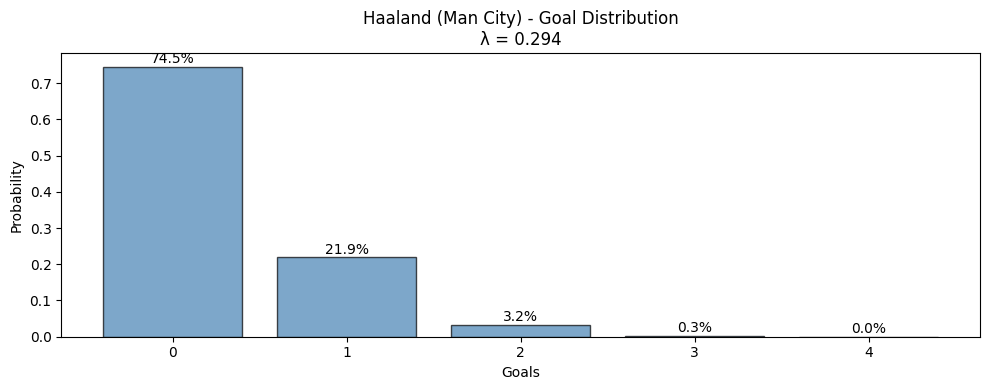


Haaland goal probabilities:
  P(0 goals) = 74.5%
  P(1+ goals) = 25.5%
  P(2+ goals) = 3.6%


In [26]:
# ----------------------------------------------------------------------
# PROBABILITY DISTRIBUTIONS (Visualization)
# ----------------------------------------------------------------------

import matplotlib.pyplot as plt
from scipy.stats import poisson

def plot_goal_distribution(player_name: str, df: pd.DataFrame):
    """Plot the Poisson distribution for a player's expected goals."""
    player = df[df['name'].str.lower().str.contains(player_name.lower())]
    if len(player) == 0:
        print(f"Player '{player_name}' not found")
        return

    p = player.iloc[0]
    lambda_goals = p['exp_goals']

    # Generate Poisson PMF
    x = np.arange(0, 5)
    pmf = poisson.pmf(x, lambda_goals)

    plt.figure(figsize=(10, 4))
    plt.bar(x, pmf, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Goals')
    plt.ylabel('Probability')
    plt.title(f"{p['name']} ({p['team']}) - Goal Distribution\nλ = {lambda_goals:.3f}")
    plt.xticks(x)

    # Add probability labels
    for i, prob in enumerate(pmf):
        plt.text(i, prob + 0.01, f'{prob:.1%}', ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\n{p['name']} goal probabilities:")
    print(f"  P(0 goals) = {poisson.pmf(0, lambda_goals):.1%}")
    print(f"  P(1+ goals) = {1 - poisson.pmf(0, lambda_goals):.1%}")
    print(f"  P(2+ goals) = {1 - poisson.cdf(1, lambda_goals):.1%}")

# Example: plot for a top scorer
plot_goal_distribution('haaland', current_players)